In [1]:
!pip install toolapi
!wget -q --show-progress https://github.com/mrx-org/toolapi-py/releases/download/v0.1.0/gre.seq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.3 MB/s eta 0:00:00
gre.seq             100%[===================>]  86.75K  --.-KB/s    in 0.01s   


In [20]:
# @title Define tools
import toolapi
from functools import cache

def on_message(msg):
    print(f"\r > {msg}", end="")
    return True

def call(url, **kwargs):
    from time import time
    start = time()
    result = toolapi.call(url, kwargs, on_message)
    print(f"\n --- done ({time() - start:.2f} s) ---")
    return result

# .seq loader: uses disseqt to convert sequence to instant events
def load_seq(path, exact_trajectories=True):
    with open(path) as f:
        file_content = f.read()
    return call(
        "wss://tool-conseq.fly.dev/tool",
        seq_file=file_content,
        exact_trajectory=exact_trajectories
    )

# phantom library: returns rescaled brainweb multi-tissue phantoms (slow)
@cache
def load_phantom(subject, res):
    affine = [
        [2.5, 0.0, 0.0, -90.0],
        [0.0, 2.5, 0.0, -108.75],
        [0.0, 0.0, 2.5, -1.25]
    ]
    return call(
        "wss://tool-phantomlib-flyio.fly.dev/tool",
        subject=subject,  # BrainWeb subject
        res_x=res[0],     # X resolution (1-434)
        res_y=res[1],     # Y resolution (1-362)
        res_z=res[2],     # Z resolution (1-434)
        affine=affine,    # orientation and FOV
    )

# not-yet-quite segmented PDG
def sim_spdg(sequence, phantom):
    return call(
        "wss://tool-rapisim.fly.dev/tool",
        sequence=sequence,
        phantom=phantom,
    )

 > Returning sequence
 --- done (2.00 s) ---
 > Returning signal
 --- done (4.51 s) ---


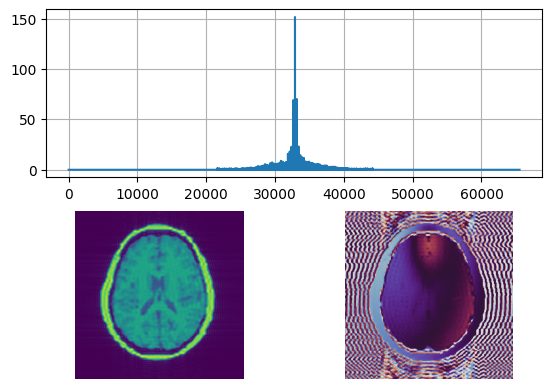

In [42]:
# @title **load .seq + load phantom + run sim** |  _with tools hosted on fly.io_
import numpy as np
import matplotlib.pyplot as plt

seq = load_seq("gre.seq", exact_trajectories=False)
phantom = load_phantom(4, (72, 87, 1))
signal = np.array(sim_spdg(seq, phantom))

# Reconstruction is done here (not via some tool)
kspace = signal.reshape(256, 256)
reco = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(kspace)))

plt.figure()
plt.subplot(211)
plt.plot(np.abs(signal))
plt.grid()
plt.subplot(223)
plt.imshow(np.abs(reco), origin="lower", vmin=0)
plt.axis("off")
plt.subplot(224)
plt.imshow(np.angle(reco), origin="lower", vmin=-np.pi, vmax=np.pi, cmap="twilight")
plt.axis("off")
plt.show()


In [31]:
print(phantom.tissues["csf"].density)

Volume(shape=[72, 87, 1], affine=[[2.5, 0.0, 0.0, -90.0], [0.0, 2.5, 0.0, -108.75], [0.0, 0.0, 2.5, -1.25]], data=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 